# Benchmark reporting — leaderboard, stability, error audit and export


## Goal
Turn structured `BenchmarkResult` outputs into an analysis-ready report **outside the mlcore core**. We generate a leaderboard with mean/SD/rank, metric-wide summary, runtime table, sample-level error audit and portable CSV/Markdown report files.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("MLCORE_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from pathlib import Path
import tempfile
from sklearn.datasets import make_classification
from mlcore import benchmark
from mlcore.benchmark import BenchmarkConfig
from mlcore.datasets import DatasetBundle, PartitionPlan


In [2]:
X,y=make_classification(n_samples=120 if DEMO_TEST else 260,n_features=12,n_informative=8,class_sep=1.05,random_state=404)
ids=[f"report_{i:04d}" for i in range(len(y))]
dataset=DatasetBundle(X=X,y=y,sample_ids=ids,feature_names=[f"f{i}" for i in range(X.shape[1])])
plan=PartitionPlan.from_predefined_folds(sample_ids=ids,fold_assignments=balanced_fold_labels(y,5),dataset_fingerprint=dataset.fingerprint)
bench=benchmark(datasets={"prepared":dataset},algorithms=("logistic_regression","random_forest","svc"),partitions={"fivefold":plan},
                config=BenchmarkConfig(metrics=("mcc","balanced_accuracy","f1","roc_auc"),seeds=(42,) if DEMO_TEST else (42,123,777),modes=("untuned",),include_baselines=True),
                model_params={"random_forest":{"n_estimators":45 if DEMO_TEST else 120,"max_depth":7}})
assert not bench.failures
metrics=bench.aggregate_metrics_frame(); runs=bench.runs_frame(); preds=bench.predictions_frame(); folds=bench.fold_metrics_frame()


In [3]:
# Leaderboard and stability report.
mcc=metrics[metrics.metric=="mcc"]
leader=(mcc.groupby("algorithm")["score"].agg(["mean","std","min","max","count"]).sort_values("mean",ascending=False))
leader["rank"]=np.arange(1,len(leader)+1)
metric_wide=(metrics.pivot_table(index=["algorithm","seed"],columns="metric",values="score").reset_index())
runtime=runs.groupby("algorithm")["elapsed_seconds"].agg(["mean","std"]).sort_values("mean")
# Sample-level audit: how often is each sample misclassified across runs?
preds=preds.copy(); preds["error"]=(preds.y_true!=preds.y_pred).astype(int)
error_audit=(preds.groupby("sample_id").agg(error_rate=("error","mean"),n_predictions=("error","size"),y_true=("y_true","first")).sort_values("error_rate",ascending=False))
leader, error_audit.head(10)


(                         mean      std       min       max  count  rank
 algorithm                                                              
 svc                  0.757596  0.00000  0.757596  0.757596      3     1
 random_forest        0.626871  0.02259  0.604702  0.649860      3     2
 logistic_regression  0.379992  0.00000  0.379992  0.379992      3     3
 dummy_classifier     0.000000  0.00000  0.000000  0.000000      3     4,
              error_rate  n_predictions  y_true
 sample_id                                     
 report_0060    1.000000             12       1
 report_0041    1.000000             12       1
 report_0117    1.000000             12       1
 report_0087    1.000000             12       1
 report_0205    1.000000             12       1
 report_0073    1.000000             12       1
 report_0253    1.000000             12       1
 report_0015    1.000000             12       1
 report_0254    1.000000             12       1
 report_0169    0.916667         

In [4]:
# Produce portable report artifacts in a temporary directory.
with tempfile.TemporaryDirectory() as tmp:
    out=Path(tmp)
    leader.to_csv(out/"leaderboard.csv")
    metric_wide.to_csv(out/"metric_summary.csv",index=False)
    error_audit.to_csv(out/"sample_error_audit.csv")
    report_text = ("# mlcore benchmark report\n\n## Leaderboard\n\n```text\n" + leader.round(4).to_string() + "\n```\n\n## Mean runtime\n\n```text\n" + runtime.round(4).to_string() + "\n```\n")




    (out/"report.md").write_text(report_text,encoding="utf-8")
    exported=sorted(p.name for p in out.iterdir())
print(report_text[:900])


# mlcore benchmark report

## Leaderboard

```text
                       mean     std     min     max  count  rank
algorithm                                                       
svc                  0.7576  0.0000  0.7576  0.7576      3     1
random_forest        0.6269  0.0226  0.6047  0.6499      3     2
logistic_regression  0.3800  0.0000  0.3800  0.3800      3     3
dummy_classifier     0.0000  0.0000  0.0000  0.0000      3     4
```

## Mean runtime

```text
                       mean     std
algorithm                          
dummy_classifier     0.0847  0.0041
svc                  0.1023  0.0011
logistic_regression  0.1528  0.0077
random_forest        0.8777  0.0213
```



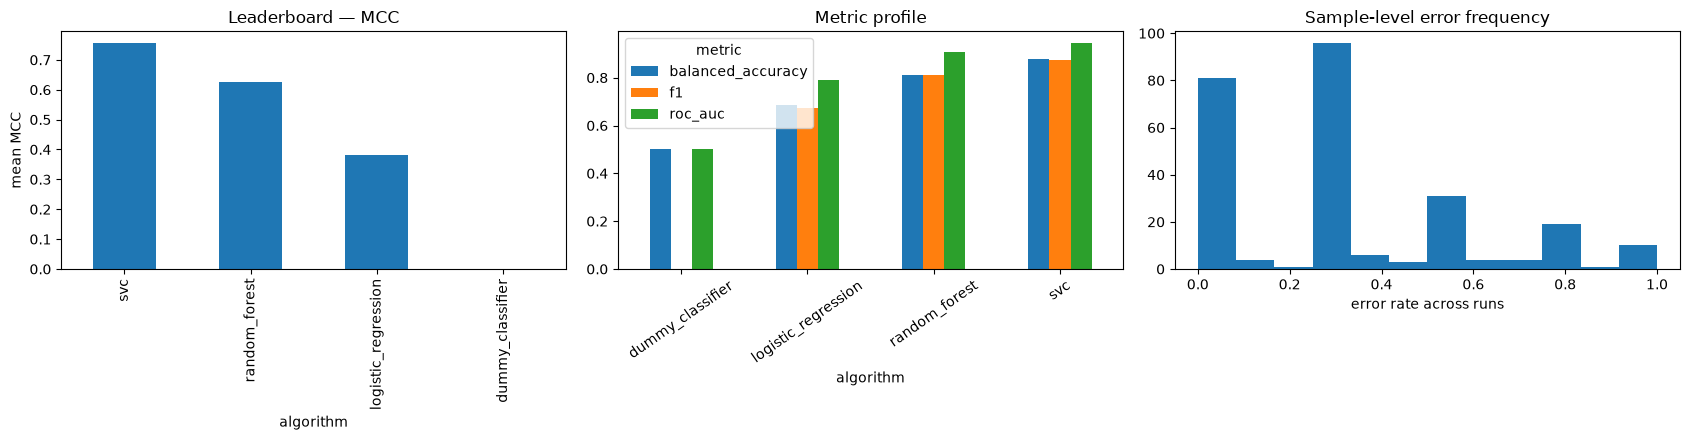

In [5]:
fig,axes=plt.subplots(1,3,figsize=(17,4.5))
leader["mean"].plot.bar(ax=axes[0]); axes[0].set(title="Leaderboard — MCC",ylabel="mean MCC")
metric_wide.groupby("algorithm")[["balanced_accuracy","f1","roc_auc"]].mean().plot.bar(ax=axes[1]); axes[1].set(title="Metric profile"); axes[1].tick_params(axis="x",rotation=35)
axes[2].hist(error_audit.error_rate,bins=12); axes[2].set(title="Sample-level error frequency",xlabel="error rate across runs")
plt.tight_layout(); FIGURE_COUNT=1


In [6]:
DEMO_CHECKS={
    "leaderboard_has_baseline_and_models":len(leader)==4,
    "metric_report_complete":set(["mcc","balanced_accuracy","f1","roc_auc"]).issubset(metric_wide.columns),
    "sample_audit_complete":len(error_audit)==dataset.n_samples,
    "traceable_prediction_count":error_audit.n_predictions.min()>0,
    "report_exports":set(exported)=={"leaderboard.csv","metric_summary.csv","report.md","sample_error_audit.csv"},
    "markdown_report":report_text.startswith("# mlcore benchmark report"),
    "figure_created":FIGURE_COUNT==1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'leaderboard_has_baseline_and_models': True,
 'metric_report_complete': True,
 'sample_audit_complete': True,
 'traceable_prediction_count': np.True_,
 'report_exports': True,
 'markdown_report': True,
 'figure_created': True}